In [1]:
import os
user = 'YS' if os.environ['USER'] in ['yitians', 'sunyitian'] else ''

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.stats import poisson
import pandas as pd
from astropy.io import fits
from astropy.io import fits
from tqdm.auto import tqdm

import numpyro
from jax import random
from numpyro.infer import MCMC, NUTS, Predictive
import numpyro.distributions as dist

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%reload_ext autoreload
%autoreload 2

/Users/sunyitian/anaconda3/envs/torch/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from einops import rearrange

import jax.numpy as jnp
from jax import jit, vmap

from numpyro.infer import SVI, Predictive, Trace_ELBO, RenyiELBO, autoguide

In [3]:
import corner
import arviz as az

import matplotlib as mpl
mpl.rc_file('matplotlibrc')

In [4]:
# Routine to project to Cartesian
from utils.cart import make_wcs, to_cart

In [5]:
# Load and downsamples Fermi counts data

counts_fits = fits.open("../data/ccube_ultracleanveto_bestpsf_joined.fits")

pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 20
i_e = 40

upsample_factor = int(pixel_size_target / pixel_size_data)

counts = counts_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / pixel_size_data):int((90 + extent) / pixel_size_data),int((90 - extent) / pixel_size_data):int((90 + extent) / pixel_size_data)]
b = counts.shape[0] // upsample_factor
counts_downsampled = counts.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

In [ ]:
counts_downsampled = np.load("../data/counts_downsampled.npy")

In [6]:
extent = 20  # Semi-extent in degrees
n_pixels = 80  # Number of pixels
pixelsize = 2 * extent / n_pixels
nside = 128

# Load standard templates and convert to Cartesian
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_plane = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0

In [6]:
def model(data):
    
    
    A_gce = numpyro.sample("A_gce", dist.Uniform(0.0, 20.0))
    A_iso = numpyro.sample("A_iso", dist.Uniform(0.0, 20.0))
    A_bub = numpyro.sample("A_bub", dist.Uniform(0.0, 20.0))
    A_psc = numpyro.sample("A_psc", dist.Uniform(0.0, 20.0))
    A_dif = numpyro.sample("A_dif", dist.Uniform(0.0, 50.0))
    
    mu = A_gce * temp_gce_cart + A_iso * temp_iso_cart + A_dif * temp_dif_cart + \
        A_psc * temp_psc_cart + A_bub * temp_bub_cart
    
    data_flattened = rearrange(data, 'x y -> (x y)', x=80)
    mu_flattened = rearrange(mu, 'x y -> (x y)', x=80)
    
    with numpyro.plate("data", len(mu_flattened)):
        numpyro.sample("obs", dist.Poisson(mu_flattened), obs=data_flattened)


In [7]:
nuts_kernel = NUTS(model)

mcmc = MCMC(nuts_kernel, num_samples=2000, num_warmup=2000)
rng_key = random.PRNGKey(0)
mcmc.run(rng_key, counts_downsampled)


sample: 100%|████████████████████████| 4000/4000 [00:08<00:00, 468.39it/s, 7 steps of size 4.94e-01. acc. prob=0.89]


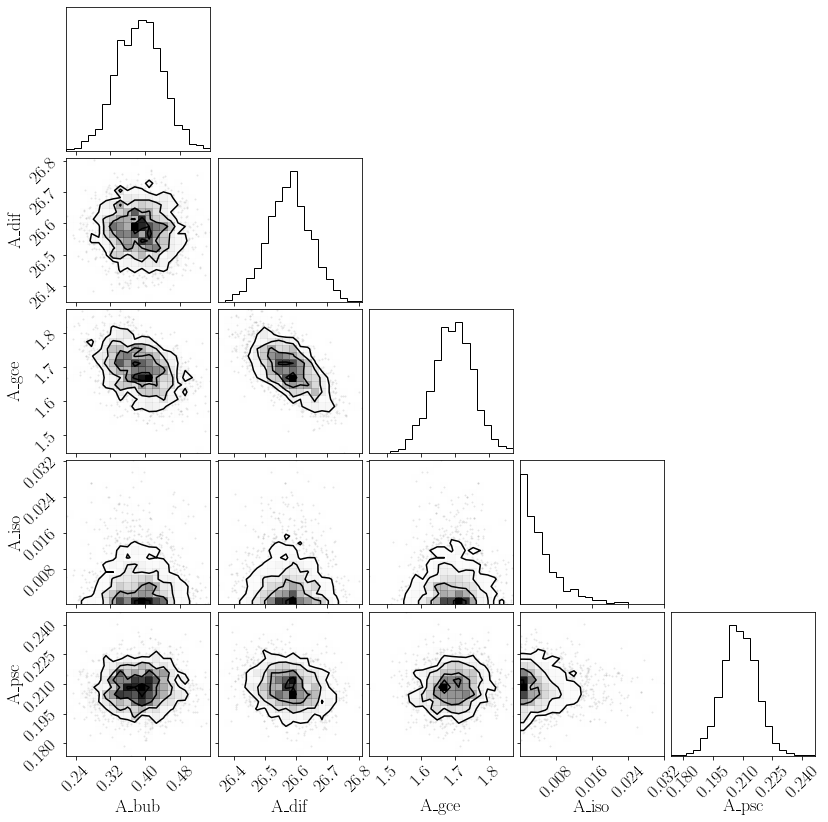

In [9]:
arviz_post = az.from_numpyro(mcmc)
corner.corner(arviz_post);

## 1. Variable NFW $\gamma$

In [11]:
def mod(dividends, divisor):
    """ Return dividends (array) mod divisor (double)
        Stolen from Nick's code
    """

    output = np.zeros(len(dividends))

    for i in range(len(dividends)): 
        output[i] = dividends[i]
        done=False
        while (not done):
            if output[i] >= divisor:
                output[i] -= divisor
            elif output[i] < 0.:
                output[i] += divisor
            else:
                done=True

    return output


def rho_NFW(r, gamma=1., r_s=20.):
    """ Generalized NFW profile
    """
    return (r / r_s) ** -gamma * (1 + (r / r_s)) ** (-3 + gamma) 

def rGC(s_ary, b_ary, l_ary, rsun=8.224):
    """ Distance to GC as a function of LOS distance, latitude, longitude
    """
    return jnp.sqrt(s_ary ** 2 - 2. * rsun * jnp.transpose(jnp.outer(s_ary, jnp.cos(b_ary) * jnp.cos(l_ary))) + rsun ** 2)

pixel_size = 0.5
extent = 20

coords_ary = jnp.deg2rad(jnp.arange(-extent, extent, pixel_size))
l_ary, b_ary = jnp.meshgrid(coords_ary, coords_ary)

npix = int(len(coords_ary) ** 2)

l_ary_flat = rearrange(l_ary, 'x y -> (x y)')
b_ary_flat = rearrange(b_ary, 'x y -> (x y)')

s_ary = jnp.linspace(0, 20, 200)

In [12]:
@jit
def get_NFW2_template_cart(gamma=1.2):
    # LOS integral of density^2
    int_rho2 = jnp.trapz(rho_NFW(rGC(s_ary, b_ary_flat, l_ary_flat), gamma=gamma) ** 2, s_ary, axis=1)
    int_rho2 = rearrange(int_rho2, '(x y) -> x y', x=len(coords_ary))
    return int_rho2 / 1000 # / jnp.mean(int_rho2[~mask_roi])

In [13]:
from utils import create_mask as cm

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_plane = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0

In [14]:
posteriors = {}

### 1.1 P6

In [15]:
# check template normalization
np.mean(temp_dif_cart)

1.99715181219745

In [16]:
def model(data):
    
    data_flattened = rearrange(data, 'x y -> (x y)', x=80)
    
    A_gce = numpyro.sample("A_gce", dist.Uniform(0.0, 10.0))
    A_iso = numpyro.sample("A_iso", dist.Uniform(0.0, 10.0))
    A_bub = numpyro.sample("A_bub", dist.Uniform(0.0, 10.0))
    A_psc = numpyro.sample("A_psc", dist.Uniform(0.0, 10.0))
    A_dif = numpyro.sample("A_dif", dist.Uniform(0.0, 50.0))

    gamma = numpyro.sample("gamma", dist.Uniform(0.1, 2.0))

    temp_gce_jax = get_NFW2_template_cart(gamma=gamma)

    mu = A_gce * temp_gce_jax + A_iso * temp_iso_cart + A_dif * temp_dif_cart + \
        A_psc * temp_psc_cart + A_bub * temp_bub_cart

    mu_flattened = rearrange(mu, 'x y -> (x y)', x=80)
    
    mask_flattened = rearrange(mask_roi, 'x y -> (x y)', x=80)

    with numpyro.plate("data", len(mu_flattened[~mask_flattened])):

        numpyro.sample("obs", dist.Poisson(mu_flattened[~mask_flattened]), obs=data_flattened[~mask_flattened])

In [ ]:
# nuts_kernel = NUTS(model, dense_mass=True, max_tree_depth=3)

# mcmc = MCMC(nuts_kernel, num_samples=2000, num_warmup=500)
# rng_key = random.PRNGKey(0)
# mcmc.run(rng_key, counts_downsampled)

In [ ]:
# arviz_post = az.from_numpyro(mcmc)
# corner.corner(arviz_post);

In [17]:
guide = autoguide.AutoMultivariateNormal(model)

optimizer = numpyro.optim.Adam(0.01)
svi = SVI(model, guide, optimizer, RenyiELBO(num_particles=1))
svi_results = svi.run(random.PRNGKey(1), 4000, counts_downsampled)
params = svi_results.params

predictive = Predictive(
            model=model, guide=guide, params=params, num_samples=2000
        )
predictions = predictive(random.PRNGKey(0), data=counts_downsampled)

posteriors['p6'] = guide.sample_posterior(rng_key=random.PRNGKey(0), params=params, sample_shape=(12000,))

100%|████████████████| 4000/4000 [01:16<00:00, 52.01it/s, init loss: 149553.5625, avg. loss [3801-4000]: 13216.7002]


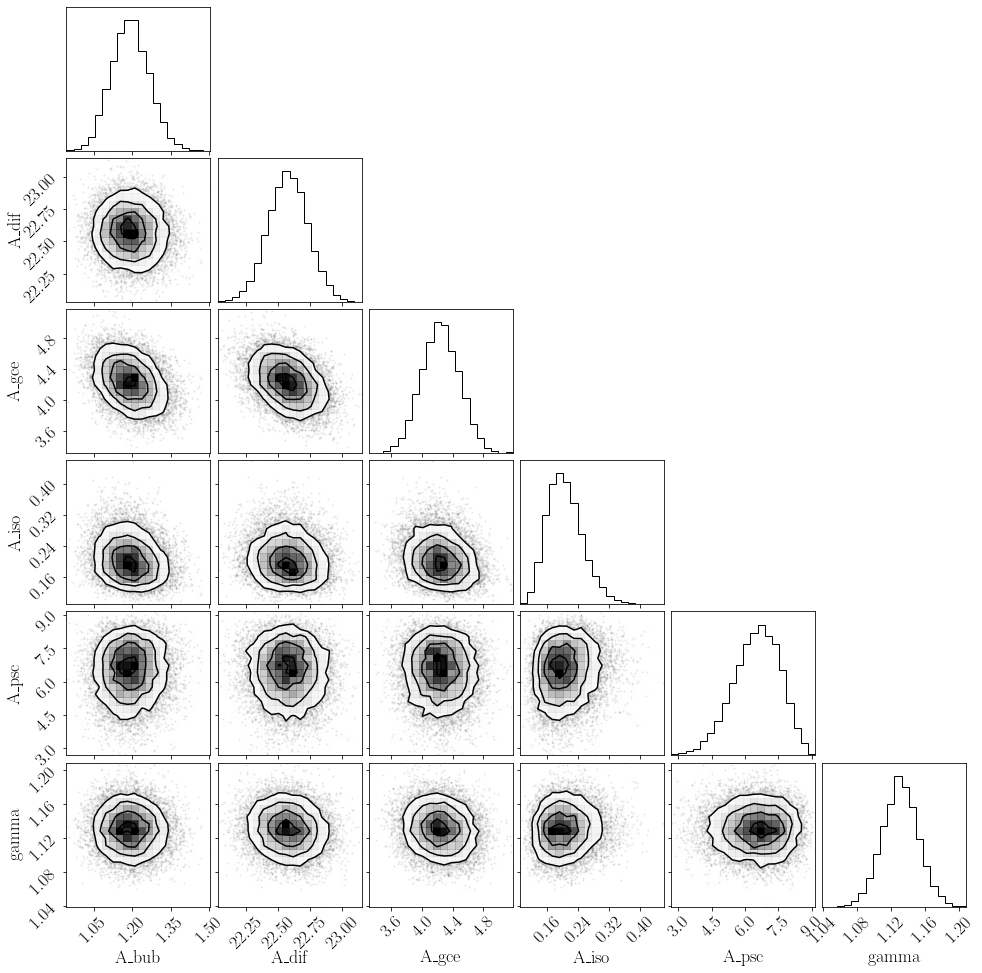

In [18]:
arviz_post = az.from_dict(posteriors['p6'])
corner.corner(arviz_post);

### 1.2 ModelO

In [19]:
n_pixels = 80
pixelsize = 0.5
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

In [20]:
# check template normalization
np.mean(temp_mO_pibrem_cart), np.mean(temp_mO_ics_cart)

(2.1563481857486146, 1.3256710802636826)

In [21]:
def model(data):
    
    data_flattened = rearrange(data, 'x y -> (x y)', x=80)
    
    A_gce = numpyro.sample("A_gce", dist.Uniform(0.0, 10.0))
    A_iso = numpyro.sample("A_iso", dist.Uniform(0.0, 10.0))
    A_bub = numpyro.sample("A_bub", dist.Uniform(0.0, 10.0))
    A_psc = numpyro.sample("A_psc", dist.Uniform(0.0, 10.0))
    A_dif_0 = numpyro.sample("A_dif_pibrem", dist.Uniform(0.0, 50.0))
    A_dif_1 = numpyro.sample("A_dif_ics", dist.Uniform(0.0, 50.0))
    gamma = numpyro.sample("gamma", dist.Uniform(0.1, 2.0))

    temp_gce_jax = get_NFW2_template_cart(gamma=gamma)

    mu = A_gce * temp_gce_jax + A_iso * temp_iso_cart + \
        A_psc * temp_psc_cart + A_bub * temp_bub_cart + \
        A_dif_0 * temp_mO_pibrem_cart + A_dif_1 * temp_mO_ics_cart

    mu_flattened = rearrange(mu, 'x y -> (x y)', x=80)
    mask_flattened = rearrange(mask_roi, 'x y -> (x y)', x=80)

    with numpyro.plate("data", len(mu_flattened[~mask_flattened])):
        numpyro.sample("obs", dist.Poisson(mu_flattened[~mask_flattened]), obs=data_flattened[~mask_flattened])

In [22]:
guide = autoguide.AutoMultivariateNormal(model)

optimizer = numpyro.optim.Adam(0.01)
svi = SVI(model, guide, optimizer, RenyiELBO(num_particles=1))
svi_results = svi.run(random.PRNGKey(1), 4000, counts_downsampled)
params = svi_results.params

predictive = Predictive(
            model=model, guide=guide, params=params, num_samples=2000
        )
predictions = predictive(random.PRNGKey(0), data=counts_downsampled)

posteriors['ModelO'] = guide.sample_posterior(rng_key=random.PRNGKey(0), params=params, sample_shape=(12000,))

100%|█████████████████| 4000/4000 [01:19<00:00, 50.58it/s, init loss: 74493.0781, avg. loss [3801-4000]: 13010.3311]


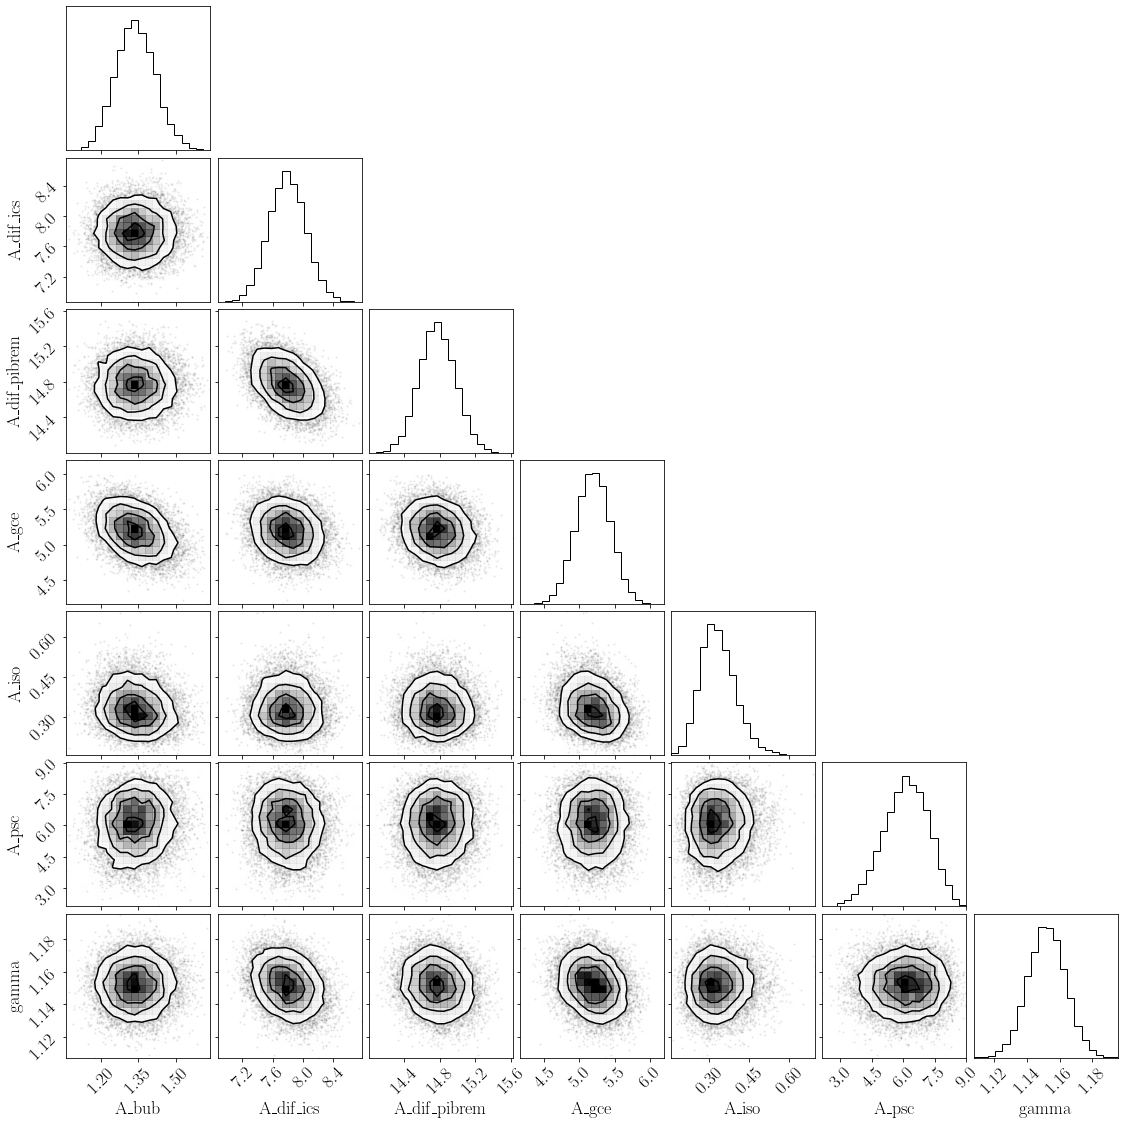

In [23]:
arviz_post = az.from_dict(posteriors['ModelO'])
corner.corner(arviz_post);

### 1.3 SkyFACT

In [24]:
temp_SkyFACT_ICS = np.load('../data/external/SkyFACT/template_SkyFACT_ICS.npy')
temp_SkyFACT_pi0 = np.load('../data/external/SkyFACT/template_SkyFACT_pi0.npy')
# temp_SkyFACT_pi0s = []
# temp_SkyFACT_pi0s.append(np.load('../data/external/SkyFACT/template_SkyFACT_Gas_ring_I.npy'))
# temp_SkyFACT_pi0s.append(np.load('../data/external/SkyFACT/template_SkyFACT_Gas_ring_II.npy'))
# temp_SkyFACT_pi0s.append(np.load('../data/external/SkyFACT/template_SkyFACT_Gas_ring_III.npy'))

In [25]:
# check template normalization
np.mean(temp_SkyFACT_ICS), np.mean(temp_SkyFACT_pi0)

(0.027086281452117767, 0.062118044254207874)

In [26]:
def model(data):
    
    data_flattened = rearrange(data, 'x y -> (x y)', x=80)
    
    A_gce = numpyro.sample("A_gce", dist.Uniform(0.0, 10.0))
    A_iso = numpyro.sample("A_iso", dist.Uniform(0.0, 10.0))
    A_bub = numpyro.sample("A_bub", dist.Uniform(0.0, 10.0))
    A_psc = numpyro.sample("A_psc", dist.Uniform(0.0, 20.0))
    A_dif_0 = numpyro.sample("A_dif_SkyFACT_ICS", dist.Uniform(0.0, 50.0))
    A_dif_1 = numpyro.sample("A_dif_SkyFACT_pi0", dist.Uniform(0.0, 50.0))
    gamma = numpyro.sample("gamma", dist.Uniform(0.1, 2.0))

    temp_gce_jax = get_NFW2_template_cart(gamma=gamma)

    mu = A_gce * temp_gce_jax + A_iso * temp_iso_cart + \
        A_psc * temp_psc_cart + A_bub * temp_bub_cart + \
        A_dif_0 * 100 * temp_SkyFACT_ICS + A_dif_1 * 100 * temp_SkyFACT_pi0

    mu_flattened = rearrange(mu, 'x y -> (x y)', x=80)
    mask_flattened = rearrange(mask_roi, 'x y -> (x y)', x=80)

    with numpyro.plate("data", len(mu_flattened[~mask_flattened])):
        numpyro.sample("obs", dist.Poisson(mu_flattened[~mask_flattened]), obs=data_flattened[~mask_flattened])

In [27]:
guide = autoguide.AutoMultivariateNormal(model)

optimizer = numpyro.optim.Adam(0.01)
svi = SVI(model, guide, optimizer, RenyiELBO(num_particles=1))
svi_results = svi.run(random.PRNGKey(1), 4000, counts_downsampled)
params = svi_results.params

predictive = Predictive(
            model=model, guide=guide, params=params, num_samples=2000
        )
predictions = predictive(random.PRNGKey(0), data=counts_downsampled)

posteriors['SkyFACT'] = guide.sample_posterior(rng_key=random.PRNGKey(0), params=params, sample_shape=(12000,))

100%|████████████████| 4000/4000 [01:17<00:00, 51.72it/s, init loss: 283536.8438, avg. loss [3801-4000]: 12264.1162]


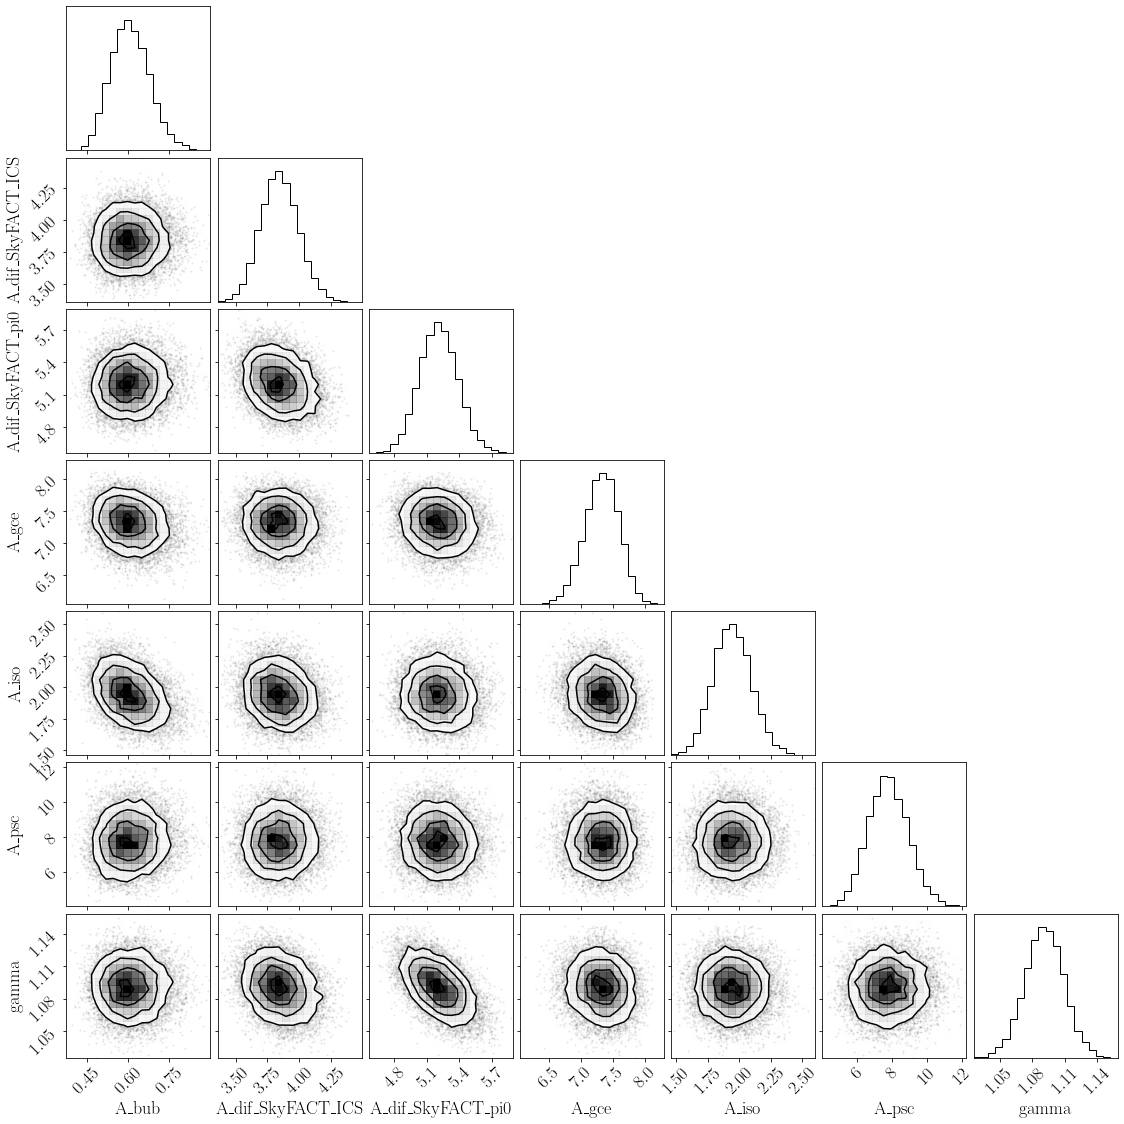

In [28]:
arviz_post = az.from_dict(posteriors['SkyFACT'])
corner.corner(arviz_post);

### 1.4 Best RotT templates

In [29]:
zenodo_dir = "/Users/smsharma/Downloads"  # Directory where Zenodo maps are located
if user == 'YS':
    zenodo_dir = '/Users/sunyitian/Dropbox (MIT)/Documents/P/ml_GCE/templates'

In [30]:
# Names of Zenodo diffuse models
dif_names = pd.read_csv(zenodo_dir+'/ZENODO_FILES/NAMING_CONVENTION_OF_DIFFUSE_EMISSION_MODELS.dat', skiprows=1, header=None, delim_whitespace=True)[1].tolist()

In [36]:
# check template normalization
max_indices = [55, 9, 54, 75, 52] # copied from 04_zenodo

for i in max_indices:
    
    dif_name = dif_names[i]
    print('\nTemplate:', dif_name, end=' ')
    dif_temps = []
    for dif_type in ['bremss', 'ICS', 'pi0']:
        print('%s: %.3f ' % (dif_type, np.mean(np.load(f'../data/external/RotT/{dif_type}_{dif_name}.npy'))), end='')


Template: d1 bremss: 10.632 ICS: 81.354 pi0: 36.746 
Template: ch bremss: 40.311 ICS: 55.499 pi0: 30.507 
Template: cv bremss: 11.514 ICS: 53.493 pi0: 36.849 
Template: 1rB bremss: 25.315 ICS: 50.351 pi0: 40.819 
Template: bf bremss: 36.404 ICS: 58.973 pi0: 22.276 

In [39]:
# best RotT templates
max_indices = [55, 9, 54, 75, 52] # copied from 04_zenodo

for i in max_indices:
    
    dif_name = dif_names[i]
    print('Template:', dif_name)
    dif_temps = []
    for dif_type in ['bremss', 'ICS', 'pi0']:
        dif_temps.append(np.load(f'../data/external/RotT/{dif_type}_{dif_name}.npy'))

    def model(data):
        data_flattened = rearrange(data, 'x y -> (x y)', x=80)

        A_gce = numpyro.sample("A_gce", dist.Uniform(0.0, 10.0))
        A_iso = numpyro.sample("A_iso", dist.Uniform(0.0, 10.0))
        A_bub = numpyro.sample("A_bub", dist.Uniform(0.0, 10.0))
        A_psc = numpyro.sample("A_psc", dist.Uniform(0.0, 20.0))
        A_dif_0 = numpyro.sample("A_dif_0", dist.Uniform(0.0, 50.0))
        A_dif_1 = numpyro.sample("A_dif_1", dist.Uniform(0.0, 50.0))
        A_dif_2 = numpyro.sample("A_dif_2", dist.Uniform(0.0, 50.0))
        gamma = numpyro.sample("gamma", dist.Uniform(0.1, 2.0))

        temp_gce_jax = get_NFW2_template_cart(gamma=gamma)

        mu = A_gce * temp_gce_jax + A_iso * temp_iso_cart + \
            A_psc * temp_psc_cart + A_bub * temp_bub_cart + \
            A_dif_0/30 * dif_temps[0] + A_dif_1/30 * dif_temps[1] + A_dif_2/30 * dif_temps[2]

        mu_flattened = rearrange(mu, 'x y -> (x y)', x=80)
        mask_flattened = rearrange(mask_roi, 'x y -> (x y)', x=80)

        with numpyro.plate("data", len(mu_flattened[~mask_flattened])):
            numpyro.sample("obs", dist.Poisson(mu_flattened[~mask_flattened]), obs=data_flattened[~mask_flattened])

    guide = autoguide.AutoMultivariateNormal(model)
    optimizer = numpyro.optim.Adam(0.01)
    svi = SVI(model, guide, optimizer, RenyiELBO(num_particles=1))
    svi_results = svi.run(random.PRNGKey(1), 4000, counts_downsampled)
    params = svi_results.params
    
    predictive = Predictive(
        model=model, guide=guide, params=params, num_samples=2000
    )
    predictions = predictive(random.PRNGKey(0), data=counts_downsampled)
    
    posteriors[dif_name] = guide.sample_posterior(rng_key=random.PRNGKey(0), params=params, sample_shape=(12000,))

Template: d1


100%|████████████████| 4000/4000 [01:29<00:00, 44.67it/s, init loss: 338894.6875, avg. loss [3801-4000]: 12698.6084]


Template: ch


100%|████████████████| 4000/4000 [01:33<00:00, 42.89it/s, init loss: 219223.9688, avg. loss [3801-4000]: 12607.9502]


Template: cv


100%|████████████████| 4000/4000 [01:18<00:00, 50.94it/s, init loss: 234744.8125, avg. loss [3801-4000]: 12664.0859]


Template: 1rB


100%|████████████████| 4000/4000 [01:17<00:00, 51.74it/s, init loss: 191016.8281, avg. loss [3801-4000]: 12739.0547]


Template: bf


100%|████████████████| 4000/4000 [01:18<00:00, 50.73it/s, init loss: 216170.0625, avg. loss [3801-4000]: 12605.2373]


## 2. Posteriors

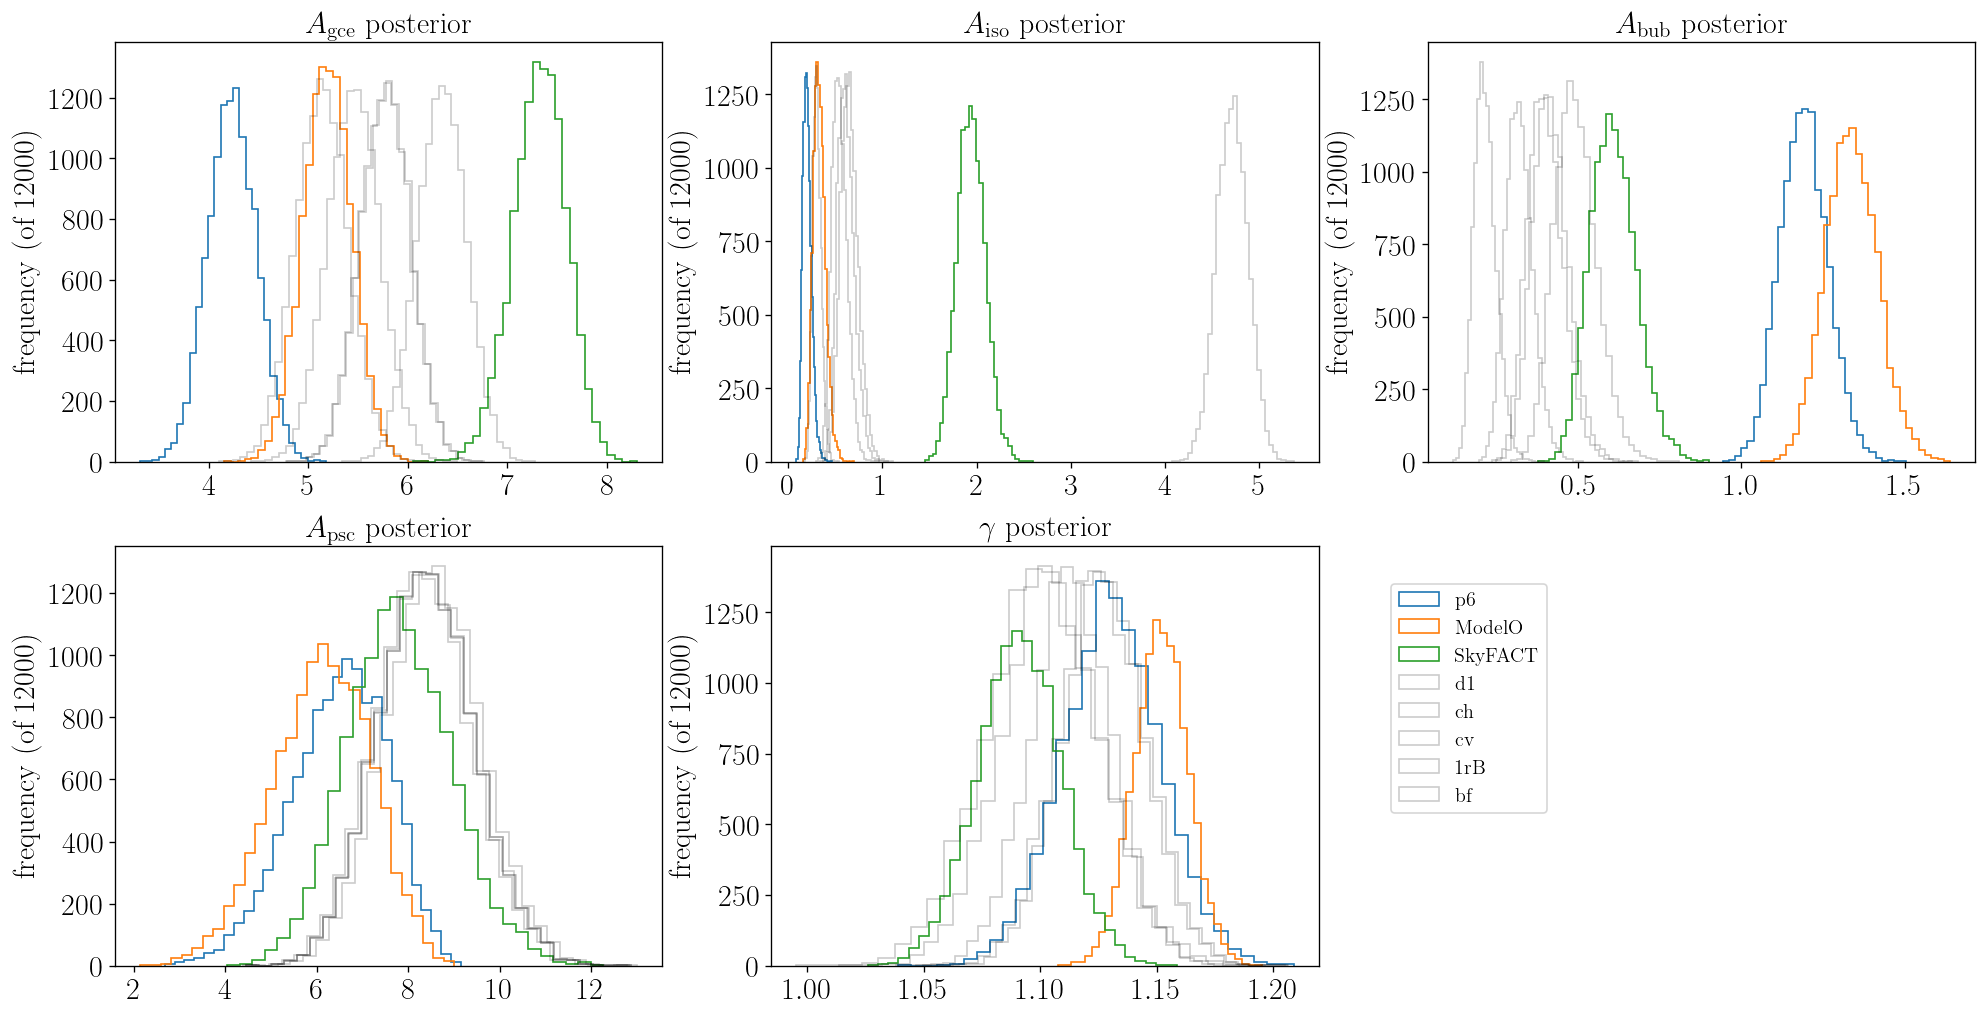

In [53]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))

var_names = ['A_gce', 'A_iso', 'A_bub', 'A_psc', 'gamma']
var_labels = [r'$A_\mathrm{gce}$', r'$A_\mathrm{iso}$', r'$A_\mathrm{bub}$', r'$A_\mathrm{psc}$', r'$\gamma$']

for i in range(5):
    for k in ['p6', 'ModelO', 'SkyFACT']:
        label = k if i==0 else ''
        axs[i//3][i%3].hist(posteriors[k][var_names[i]].flatten(), bins=30, label=label, histtype='step')
    for k in [dif_names[i] for i in max_indices]:
        label = k if i==0 else ''
        axs[i//3][i%3].hist(posteriors[k][var_names[i]].flatten(), bins=30, label=label, histtype='step', color='k', alpha=0.2)
    axs[i//3][i%3].set(title=var_labels[i]+' posterior', ylabel='frequency (of 12000)')
axs[-1][-1].axis('off')
fig.legend(fontsize=12, loc=(0.7, 0.2));